In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Bootstrap Analysis: Learnability across 10 bootstraps (brainsc_simbrainlabels)

In [113]:
import pandas as pd
import os
os.makedirs('results', exist_ok=True)
BOOTSTRAP_DIR = '/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/ctProfilePipeline/data/brainsc_simbrainlabels'

dfs = []
for b in range(1, 11):
    path = os.path.join(BOOTSTRAP_DIR, str(b), 'EGAD', 'brain_profiles_EGAD.csv')
    tmp = pd.read_csv(path, index_col=0).reset_index()
    tmp['bootstrap'] = b
    dfs.append(tmp)

df_boot = pd.concat(dfs, ignore_index=True)
df_boot['Q'] = df_boot['index'].str.split('_').str[-1]
df_boot = df_boot[df_boot['Q'] != 'Q1']
df_boot['group'] = df_boot['Q'].map({'Q2': 'Non-enriched', 'Q3': 'Brain-Enriched'})
df_boot

,index,auc,avg_node_degree,degree_null_auc,bootstrap,Q,group
999,SIMGO_1_Q2,0.493803,516.374768,0.463905,1,Q2,Non-enriched
1000,SIMGO_2_Q2,0.506424,185.494499,0.341603,1,Q2,Non-enriched
1001,SIMGO_3_Q2,0.472850,705.468985,0.536376,1,Q2,Non-enriched
1002,SIMGO_4_Q2,0.589435,532.471649,0.421571,1,Q2,Non-enriched
1003,SIMGO_5_Q2,0.585485,270.306196,0.391177,1,Q2,Non-enriched
...,...,...,...,...,...,...,...
29965,SIMGO_995_Q3,0.681478,927.687247,0.440791,10,Q3,Brain-Enriched
29966,SIMGO_996_Q3,0.696992,765.178445,0.391414,10,Q3,Brain-Enriched
29967,SIMGO_997_Q3,0.741221,682.430667,0.336429,10,Q3,Brain-Enriched
29968,SIMGO_998_Q3,0.766833,535.819476,0.316884,10,Q3,Brain-Enriched


/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 1.5 x 1 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/bootstrap_learnability_boxplot.png
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 1.5 x 1 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/bootstrap_learnability_boxplot.pdf


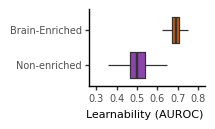

<ggplot: (8748795083906)>

In [114]:
from plotnine import *

group_colors = {'Non-enriched': '#8E44AD', 'Brain-Enriched': '#D55E00'}

p = (
    ggplot(
        df_boot,
        aes(x='group', y='auc', fill='group')
    )
    + geom_boxplot(outlier_alpha=0)
    + scale_x_discrete(limits=['Non-enriched', 'Brain-Enriched'])
    + scale_fill_manual(values=group_colors)
    + labs(
        x='',
        y='Learnability (AUROC)'
    )
    + theme_classic()
    + theme(
        figure_size=(1.5, 1),
        axis_text_x=element_text(rotation=0, size=7),
        axis_text_y=element_text(rotation=0, size=7),
        axis_title_y=element_text(size=8),
        axis_title_x=element_text(size=8),
        legend_position='none'
    )
    + coord_flip()
)

p.save('results/bootstrap_learnability_boxplot.png', dpi=300)
p.save('results/bootstrap_learnability_boxplot.pdf')
p

In [115]:
from scipy import stats

df_boot['go_num'] = df_boot['index'].str.split('_').str[1]
df_agg_boot = df_boot.groupby(['go_num', 'group'])['auc'].mean().reset_index()

ne = df_agg_boot[df_agg_boot['group'] == 'Non-enriched']['auc']
be = df_agg_boot[df_agg_boot['group'] == 'Brain-Enriched']['auc']
t_stat, p_val = stats.ttest_ind(ne, be)

ttest_df = pd.DataFrame([{
    'comparison': 'Non-enriched vs Brain-Enriched',
    'mean_Non-enriched': ne.mean(),
    'mean_Brain-Enriched': be.mean(),
    't_stat': t_stat,
    'p_value': p_val
}])
ttest_df.to_csv('results/bootstrap_ttest_results.csv', index=False)
ttest_df

,comparison,mean_Non-enriched,mean_Brain-Enriched,t_stat,p_value
0,Non-enriched vs Brain-Enriched,0.500582,0.683134,-111.883582,0.0


In [116]:
import numpy as np

COMP_PATH = '/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/simgobrain_allcells/master_melted_df.csv.gz'
df_comp = pd.read_csv(COMP_PATH)
df_comp = df_comp[df_comp['organism_part'].str.startswith('exp')]
df_comp['Q'] = df_comp['index'].str.split('_').str[-1]
df_comp = df_comp[df_comp['Q'] != 'Q1']

# Mean AUC per SIMGO across bootstraps
agg_comp = df_comp.groupby(['index', 'Q'])['auc'].mean().reset_index()
agg_comp = agg_comp.rename(columns={'auc': 'auc_comp'})

# Mean AUC per SIMGO across 10 ct profile bootstraps
agg_ct = df_boot.groupby(['index', 'Q', 'group'])['auc'].mean().reset_index()
agg_ct = agg_ct.rename(columns={'auc': 'auc_ct'})

scatter_df = agg_ct.merge(agg_comp[['index', 'auc_comp']], on='index')
scatter_df

,index,Q,group,auc_ct,auc_comp
0,SIMGO_100_Q2,Q2,Non-enriched,0.562773,0.554480
1,SIMGO_100_Q3,Q3,Brain-Enriched,0.688816,0.685063
2,SIMGO_101_Q2,Q2,Non-enriched,0.559979,0.511049
3,SIMGO_101_Q3,Q3,Brain-Enriched,0.690678,0.676639
4,SIMGO_102_Q2,Q2,Non-enriched,0.562757,0.572302
...,...,...,...,...,...
1993,SIMGO_999_Q3,Q3,Brain-Enriched,0.694738,0.678464
1994,SIMGO_99_Q2,Q2,Non-enriched,0.514265,0.540319
1995,SIMGO_99_Q3,Q3,Brain-Enriched,0.683243,0.682180
1996,SIMGO_9_Q2,Q2,Non-enriched,0.425005,0.419670


/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 1.5 x 1.5 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/scatter_non_enriched.png
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 1.5 x 1.5 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/scatter_non_enriched.pdf


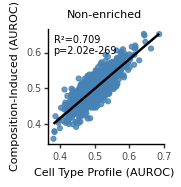

<ggplot: (8749380244161)>

In [117]:
from plotnine import *
from scipy.stats import pearsonr
import numpy as np

ne_df = scatter_df[scatter_df['group'] == 'Non-enriched'].copy()
r, pval = pearsonr(ne_df['auc_ct'], ne_df['auc_comp'])
r2 = r**2
label = f'R²={r2:.3f}\np={pval:.2e}'

p = (
    ggplot(ne_df, aes(x='auc_ct', y='auc_comp'))
    + geom_point(size=1.5, alpha=0.8, color='steelblue')
    + stat_smooth(method='lm', color='black', size=1, se=False)
    + annotate('text', x=ne_df['auc_ct'].min(), y=ne_df['auc_comp'].max(),
               label=label, ha='left', va='top', size=7)
    + labs(
        x='Cell Type Profile (AUROC)',
        y='Composition-Induced (AUROC)',
        title='Non-enriched'
    )
    + theme_classic()
    + theme(
        text=element_text(size=8),
        axis_text_x=element_text(size=7),
        axis_text_y=element_text(size=7),
        figure_size=(1.5, 1.5)
    )
)

p.save('results/scatter_non_enriched.png', dpi=300)
p.save('results/scatter_non_enriched.pdf', dpi=300)
p

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 3 x 2 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/scatter_brain_enriched.png
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 3 x 2 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/scatter_brain_enriched.pdf


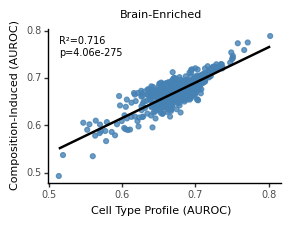

<ggplot: (8748794337985)>

In [118]:
be_df = scatter_df[scatter_df['group'] == 'Brain-Enriched'].copy()
r, pval = pearsonr(be_df['auc_ct'], be_df['auc_comp'])
r2 = r**2
label = f'R²={r2:.3f}\np={pval:.2e}'

p = (
    ggplot(be_df, aes(x='auc_ct', y='auc_comp'))
    + geom_point(size=1.5, alpha=0.8, color='steelblue')
    + stat_smooth(method='lm', color='black', size=1, se=False)
    + annotate('text', x=be_df['auc_ct'].min(), y=be_df['auc_comp'].max(),
               label=label, ha='left', va='top', size=7)
    + labs(
        x='Cell Type Profile (AUROC)',
        y='Composition-Induced (AUROC)',
        title='Brain-Enriched'
    )
    + theme_classic()
    + theme(
        text=element_text(size=8),
        axis_text_x=element_text(size=7),
        axis_text_y=element_text(size=7),
        figure_size=(3, 2)
    )
)

p.save('results/scatter_brain_enriched.png', dpi=300)
p.save('results/scatter_brain_enriched.pdf', dpi=300)
p

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 1.5 x 1.5 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/scatter_combined.png
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 1.5 x 1.5 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/scatter_combined.pdf


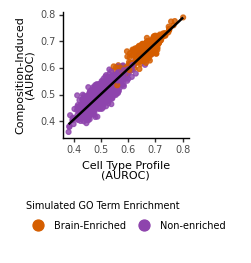

<ggplot: (8748867633580)>

In [126]:
# Compute per-group R2 for annotation
annot_rows = []
for grp in ['Non-enriched', 'Brain-Enriched']:
    sub = scatter_df[scatter_df['group'] == grp]
    r, pval = pearsonr(sub['auc_ct'], sub['auc_comp'])
    annot_rows.append({'group': grp, 'auc_ct': sub['auc_ct'].max(),
                       'auc_comp': sub['auc_comp'].max() + 0.03 - len(annot_rows) * 0.06,
                       'label': f'R²={r**2:.3f}\np={pval:.2e}'})
annot_df = pd.DataFrame(annot_rows)

group_colors = {'Non-enriched': '#8E44AD', 'Brain-Enriched': '#D55E00'}

p = (
    ggplot(scatter_df, aes(x='auc_ct', y='auc_comp', color='group'))
    + geom_point(size=1.5, alpha=0.8)
    + stat_smooth(method='lm', color='black', size=1, se=False)
    # + geom_text(aes(x='auc_ct', y='auc_comp', label='label', color='group'),
    #             data=annot_df, ha='right', va='top', size=8, inherit_aes=False)
    + labs(
        x='Cell Type Profile\n(AUROC)',
        y='Composition-Induced\n(AUROC)',
        color='Simulated GO Term Enrichment'
    )
    + scale_color_manual(values=group_colors)
    + guides(color=guide_legend(override_aes={'size': 4, 'alpha': 1.0}))
    + theme_classic()
    + theme(
        text=element_text(size=8),
        axis_text_x=element_text(size=7),
        axis_text_y=element_text(size=7),
        legend_position=(0.5, -0.45),
        legend_direction='horizontal',
        legend_title=element_text(size=7),
        legend_text=element_text(size=7),
        legend_key=element_blank(),
        legend_background=element_blank(),
        legend_box_spacing=0.01,
        plot_margin=0.08,
        figure_size=(1.5, 1.5)
    )
)

p.save('results/scatter_combined.png', dpi=300)
p.save('results/scatter_combined.pdf', dpi=300)
p

In [120]:
from scipy.stats import pearsonr

rows = []
for grp in ['Non-enriched', 'Brain-Enriched']:
    sub = scatter_df[scatter_df['group'] == grp]
    r, pval = pearsonr(sub['auc_ct'], sub['auc_comp'])
    rows.append({'group': grp, 'pearson_r': r, 'r2': r**2, 'p_value': pval})

pearson_df = pd.DataFrame(rows)
pearson_df.to_csv('results/scatter_pearson_r2.csv', index=False)
pearson_df

,group,pearson_r,r2,p_value
0,Non-enriched,0.841959,0.708894,2.024271e-269
1,Brain-Enriched,0.846435,0.716452,4.061935e-275
